In [33]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

import sys
sys.path.append("..")

from dataset_loader import TORGO, ParameterizedTORGO

In [2]:
torgo_param = ParameterizedTORGO("torgo_nopreemph_hamming256_lengths_prompts_categories.csv")

Loaded TORGO_CSV dataset with 17627 entries from torgo_nopreemph_hamming256_lengths_prompts_categories.csv.


In [55]:
subset = torgo_param.subset(
    categories=['restricted_sentence', 'short_word', 'non_word'],
    microphones=['head']
)
subset

In [56]:
df = subset.df.copy()

X_train_list, X_val_list, X_test_list = [], [], []
y_train_list, y_val_list, y_test_list = [], [], []

for cat in ['non_word','short_word', 'restricted_sentence']:
    df_cat = df[df['prompt_category'] == cat]

    df_train, df_temp = train_test_split(
        df_cat, test_size=0.3, random_state=42, stratify=df_cat['label'])

    df_val, df_test = train_test_split(
        df_temp, test_size=1/3, random_state=42, stratify=df_temp['label'])

    #feature_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop('label')
    feature_cols = [col for col in df.columns if col not in ['Unnamed: 0','label', 'path', 'prompt', 'prompt_category', 'length_samples','length_seconds']]

    X_train_list.append(df_train[feature_cols])
    y_train_list.append(df_train['label'])

    X_val_list.append(df_val[feature_cols])
    y_val_list.append(df_val['label'])

    X_test_list.append(df_test[feature_cols])
    y_test_list.append(df_test['label'])

X_train = pd.concat(X_train_list).reset_index(drop=True)
y_train = pd.concat(y_train_list).reset_index(drop=True)

X_val = pd.concat(X_val_list).reset_index(drop=True)
y_val = pd.concat(y_val_list).reset_index(drop=True)

X_test = pd.concat(X_test_list).reset_index(drop=True)
y_test = pd.concat(y_test_list).reset_index(drop=True)

In [57]:
X_train = X_train.dropna()
y_train = y_train[X_train.index]

X_val = X_val.dropna()
y_val = y_val[X_val.index]

X_test = X_test.dropna()
y_test = y_test[X_test.index]

In [58]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [59]:
svm = SVC(kernel='rbf', C=1.0, random_state=42)
svm.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [60]:
y_val_pred_svm = svm.predict(X_val_scaled)
print("=== SVM - Walidacja ===")
print(classification_report(y_val, y_val_pred_svm))

=== SVM - Walidacja ===
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1030
           1       0.99      0.92      0.96       588

    accuracy                           0.97      1618
   macro avg       0.97      0.96      0.97      1618
weighted avg       0.97      0.97      0.97      1618



In [61]:
y_test_pred_svm = svm.predict(X_test_scaled)
print("=== SVM - Test ===")
print(classification_report(y_test, y_test_pred_svm))

=== SVM - Test ===
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       515
           1       0.98      0.92      0.95       295

    accuracy                           0.96       810
   macro avg       0.97      0.95      0.96       810
weighted avg       0.96      0.96      0.96       810



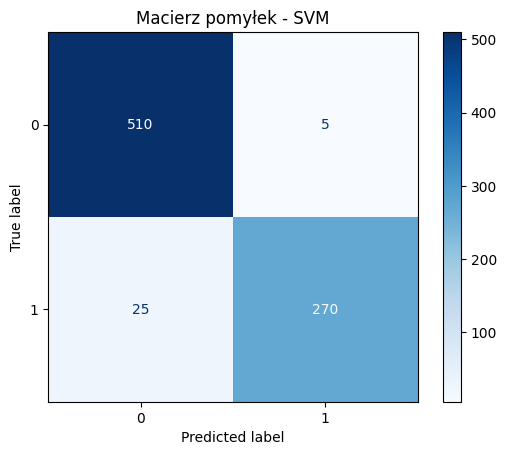

In [62]:
cm = confusion_matrix(y_test, y_test_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Macierz pomyłek - SVM")
plt.show()

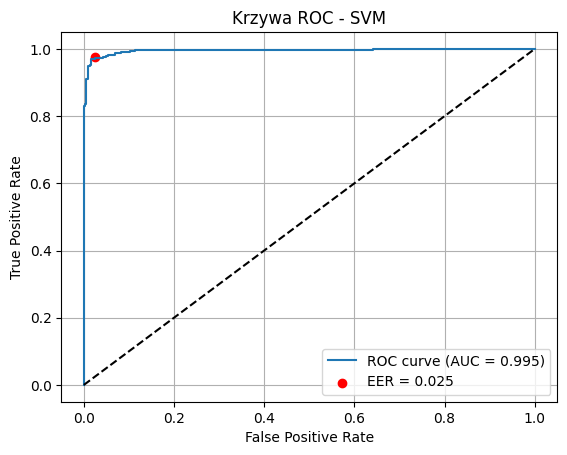

SVM - AUC: 0.995
SVM - EER: 0.025


In [63]:
y_score_svm = svm.decision_function(X_test_scaled)
fpr, tpr, thresholds = roc_curve(y_test, y_score_svm)
auc_score = roc_auc_score(y_test, y_score_svm)
    
# EER calculation
fnr = 1 - tpr
eer_threshold = thresholds[np.nanargmin(np.absolute((fnr - fpr)))]
eer = fpr[np.nanargmin(np.absolute((fnr - fpr)))]
    
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.scatter(eer, 1 - eer, marker='o', color='red', label=f'EER = {eer:.3f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Krzywa ROC - SVM')
plt.legend(loc='lower right')
plt.grid()
plt.show()
    
print(f"SVM - AUC: {auc_score:.3f}")
print(f"SVM - EER: {eer:.3f}")

In [64]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [65]:
y_val_pred_rf = rf.predict(X_val)
print("=== Random Forest - Walidacja ===")
print(classification_report(y_val, y_val_pred_rf))

=== Random Forest - Walidacja ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1030
           1       0.99      0.95      0.97       588

    accuracy                           0.98      1618
   macro avg       0.98      0.97      0.98      1618
weighted avg       0.98      0.98      0.98      1618



In [66]:
y_test_pred_rf = rf.predict(X_test)
print("=== Random Forest - Test ===")
print(classification_report(y_test, y_test_pred_rf))

=== Random Forest - Test ===
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       515
           1       0.99      0.93      0.96       295

    accuracy                           0.97       810
   macro avg       0.98      0.96      0.97       810
weighted avg       0.97      0.97      0.97       810



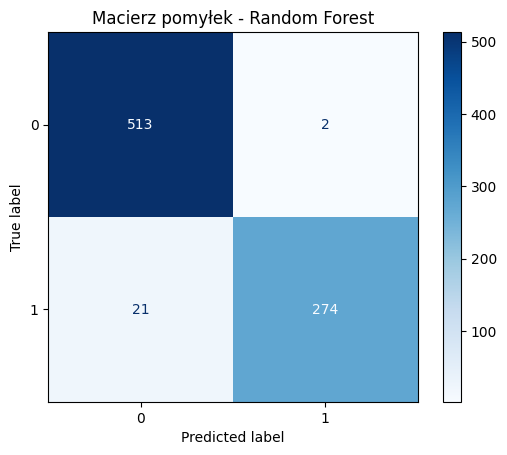

In [67]:
cm = confusion_matrix(y_test, y_test_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Macierz pomyłek - Random Forest")
plt.show()

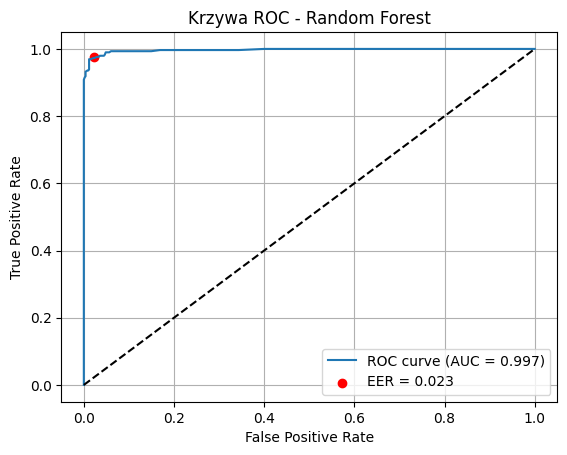

Random Forest - AUC: 0.997
Random Forest - EER: 0.023


In [68]:
y_score_rf = rf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_score_rf)
auc_score = roc_auc_score(y_test, y_score_rf)

fnr = 1 - tpr
eer_threshold = thresholds[np.nanargmin(np.absolute((fnr - fpr)))]
eer = fpr[np.nanargmin(np.absolute((fnr - fpr)))]
    
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.scatter(eer, 1 - eer, marker='o', color='red', label=f'EER = {eer:.3f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Krzywa ROC - Random Forest')
plt.legend(loc='lower right')
plt.grid()
plt.show()
    
print(f"Random Forest - AUC: {auc_score:.3f}")
print(f"Random Forest - EER: {eer:.3f}")